In [4]:
import os
from contextlib import redirect_stdout
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import src.config as cfg
import src._1_data_prep as dp
import src._2_power_flow_optimization as pfo
from src._3_overall_cost import generer_bilan_financier


In [5]:
df_raw = dp.load_and_prepare_data()
dp.sort_ship_columns(df_raw, start_idx=6, First_ship=0, Last_ship=70)

,private_MWh,price_EUR_MWh,business_MWh,CO2_g_MWh,t2m_C,radiation_solaire_factor,AIDANOVA,MSC EURIBIA,IONA,NORWEGIAN PRIMA,...,EUROPA,SEABOURN VENTURE,STAR PRIDE,DEUTSCHLAND,HAMBURG,CORINTHIAN,WORLD VOYAGER,HANSEATIC SPIRIT,HEBRIDEAN SKY,NOORDERLICHT
Date,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,0.202830,26.800000,0.945704,4730.0,0.75967,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 01:00:00,0.197758,32.800000,0.924756,4600.0,0.66458,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 02:00:00,0.192327,31.140000,0.927263,3920.0,0.58303,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 03:00:00,0.187711,32.800000,0.928286,3790.0,0.46475,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 04:00:00,0.186129,33.100000,0.963000,4050.0,0.43105,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00,0.253905,10.000000,1.074408,7140.0,-1.55344,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-12-31 20:00:00,0.245642,11.100000,1.070172,6780.0,-1.50022,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-12-31 21:00:00,0.238986,14.900000,1.043138,7190.0,-1.51035,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


import os
from contextlib import redirect_stdout
import numpy as np
import pandas as pd
from tqdm import tqdm

import src.config as cfg
import src._1_data_prep as dp
import src._2_power_flow_optimization as pfo
from src._3_overall_cost import generer_bilan_financier

# 1. Définition des paramètres de l'étude
solar_capacities = list(range(1, 11)) # De 1 à 10 MW (pas de 1)
num_ships_list = list(range(0, 70))   # De 0 à 69 navires inclus

# 2. Chargement des données brutes et tri UNIQUE
print("Chargement des données brutes...")
df_raw = dp.load_and_prepare_data()

print("Tri des navires par consommation (une seule fois)...")
# On trie tous les navires (Last_ship=None par défaut ou on s'assure de tout prendre)
df_sorted = dp.sort_ship_columns(df_raw, start_idx=6)

results = []
total_iterations = len(solar_capacities) * len(num_ships_list)

print("="*50)
print(" Lancement de l'étude paramétrique")
print("="*50)

# 3. Double boucle avec barre de progression TQDM
with tqdm(total=total_iterations, desc="Simulations en cours") as pbar:
    for num_ships in num_ships_list:
        
        # Découpage ultra-rapide : les 6 colonnes de base + 'num_ships' colonnes de navires
        df_sim = df_sorted.iloc[:, :6 + num_ships].copy()
        
        for solar_cap in solar_capacities:
            # Mise à jour de la configuration
            cfg.SOLAR_CAPACITY_MW = solar_cap
            
            # Création du réseau PyPSA
            network = pfo.create_pypsa_network(df_sim, solar_cap, True)
            
            # Blocage des 'print' parasites de PyPSA
            with open(os.devnull, 'w') as f, redirect_stdout(f):
                status, condition = network.optimize()
                
                if status == "ok":
                    res = generer_bilan_financier(network)
                    bilan_net_k_eur = res["bilan"] / 1000  # k€
                else:
                    bilan_net_k_eur = np.nan
                    
            # Enregistrement du résultat
            results.append({
                "Taille PV (MW)": solar_cap,
                "Nombre de navires": num_ships,
                "Bilan Net (k€)": bilan_net_k_eur
            })
            
            pbar.update(1)

# 4. Sauvegarde dans un fichier CSV
df_results = pd.DataFrame(results)
df_results.to_csv("resultats_simulation.csv", index=False)
print("\nSimulations terminées. Résultats sauvegardés dans 'resultats_simulation.csv'.")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# 1. Chargement des résultats
df_results = pd.read_csv("resultats_simulation.csv")

# 2. Préparation des variables pour le graphique
solar_capacities = df_results["Taille PV (MW)"].unique()
num_ships_list = df_results["Nombre de navires"].unique()

# ==========================================
# GÉNÉRATION DU GRAPHIQUE
# ==========================================
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(12, 7))

# Création d'une palette de couleurs continue (dégradé)
# 'viridis', 'plasma', ou 'coolwarm' rendent très bien pour ce type de variation
cmap = plt.get_cmap('viridis')
norm = mcolors.Normalize(vmin=min(num_ships_list), vmax=max(num_ships_list))

# Tracé des courbes
for num_ships in num_ships_list:
    df_plot = df_results[df_results["Nombre de navires"] == num_ships]
    
    # La couleur dépend du nombre de navires
    color = cmap(norm(num_ships))
    
    # On trace la ligne
    ax.plot(df_plot["Taille PV (MW)"], df_plot["Bilan Net (k€)"], 
            linewidth=1.5, color=color, alpha=0.8)
    
    # Remplissage très léger sous chaque courbe pour créer l'effet "zone de couleur"
    ax.fill_between(df_plot["Taille PV (MW)"], df_plot["Bilan Net (k€)"], 
                    color=color, alpha=0.03)

# Ligne d'équilibre (0 k€) bien visible
ax.axhline(0, color='red', linestyle='--', linewidth=2, label='Seuil Rentabilité (0 k€)')

# Esthétique générale
ax.set_title("Bilan Net Annuel selon la Taille du Solaire et le Nombre de Navires", 
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Capacité Solaire PV installée (MW)", fontsize=12, fontweight='bold')
ax.set_ylabel("Bilan Net (k€)", fontsize=12, fontweight='bold')
ax.set_xticks(solar_capacities)

# Formatage de l'axe Y (séparateur de milliers)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)).replace(',', ' ')))

# Ajout d'une barre de couleur (Colorbar) au lieu d'une légende surchargée
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Nombre de navires connectés (Top N)", fontsize=12, fontweight='bold', rotation=270, labelpad=20)

# Légende classique uniquement pour le seuil de rentabilité
ax.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig("bilan_gradient_navires.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
df_results = pd.read_csv("resultats_simulation.csv")
df_results

,Taille PV (MW),Nombre de navires,Bilan Net (k€)
0,1,0,-1153.028352
1,2,0,-1219.940503
2,3,0,-1278.543030
3,4,0,-1303.027592
4,5,0,-1341.987434
...,...,...,...
695,6,69,3548.733248
696,7,69,3493.698276
697,8,69,3434.502672
698,9,69,3374.729236


/var/folders/_p/lntvskx96x323cvnklm36kvh0000gn/T/ipykernel_75833/2864312029.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("viridis", len(pivot.columns))


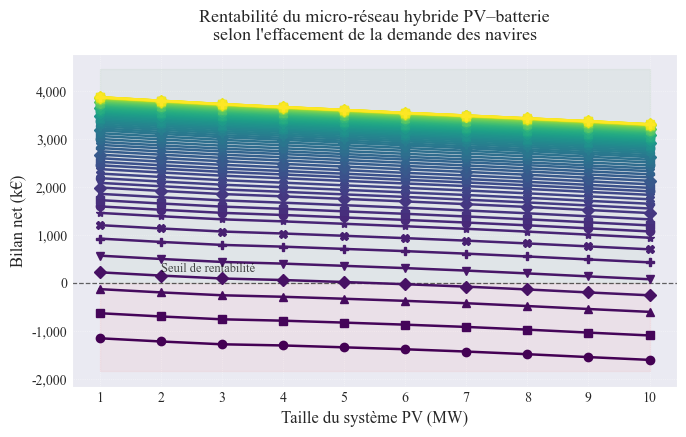

✓ Figure sauvegardée : rentabilite_microgrid.pdf / .png


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── 1. Données ────────────────────────────────────────────────────────────────
df_results = pd.read_csv("resultats_simulation.csv")

# Pivot : lignes = Taille PV, colonnes = Nombre de navires
pivot = df_results.pivot(
    index="Taille PV (MW)",
    columns="Nombre de navires",
    values="Bilan Net (k€)"
)

# ── 2. Style publication ───────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "DejaVu Serif"],
    "font.size":        11,
    "axes.labelsize":   12,
    "axes.titlesize":   13,
    "legend.fontsize":  10,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
    "axes.linewidth":   0.8,
    "grid.linewidth":   0.5,
    "lines.linewidth":  1.8,
    "lines.markersize": 6,
})

# Palette colorblind-safe (ordonnée par nb navires croissant)
cmap   = plt.cm.get_cmap("viridis", len(pivot.columns))
colors = [cmap(i) for i in range(len(pivot.columns))]
markers = ["o", "s", "^", "D", "v", "P", "X", "*"]

# ── 3. Figure ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))

for idx, (n_ships, color) in enumerate(zip(pivot.columns, colors)):
    ax.plot(
        pivot.index,
        pivot[n_ships],
        color=color,
        marker=markers[idx % len(markers)],
        label=f"{n_ships} navire{'s' if n_ships > 1 else ''}",
        zorder=3,
    )

# Ligne de rentabilité nulle
ax.axhline(0, color="black", linewidth=0.9, linestyle="--", alpha=0.6, zorder=2)
ax.fill_between(pivot.index, 0, pivot.max().max() * 1.15,
                alpha=0.04, color="green", zorder=1)
ax.fill_between(pivot.index, pivot.min().min() * 1.15, 0,
                alpha=0.04, color="red", zorder=1)

# ── 4. Axes & annotations ──────────────────────────────────────────────────────
ax.set_xlabel("Taille du système PV (MW)")
ax.set_ylabel("Bilan net (k€)")
ax.set_title(
    "Rentabilité du micro-réseau hybride PV–batterie\n"
    "selon l'effacement de la demande des navires",
    pad=10,
)

ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.grid(True, linestyle=":", alpha=0.6)
ax.set_axisbelow(True)

# Annotation seuil de rentabilité
ax.annotate(
    "Seuil de rentabilité",
    xy=(pivot.index[1], 0),
    xytext=(0, 8),
    textcoords="offset points",
    fontsize=9, color="black", alpha=0.7,
    ha="left",
)

# Légende


# ── 5. Export ──────────────────────────────────────────────────────────────────
fig.tight_layout()
fig.savefig("rentabilite_microgrid.pdf", dpi=300, bbox_inches="tight")
fig.savefig("rentabilite_microgrid.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Figure sauvegardée : rentabilite_microgrid.pdf / .png")

/var/folders/_p/lntvskx96x323cvnklm36kvh0000gn/T/ipykernel_75833/1669990301.py:39: RuntimeWarning: divide by zero encountered in log10
  log_arr = np.log10(arr)


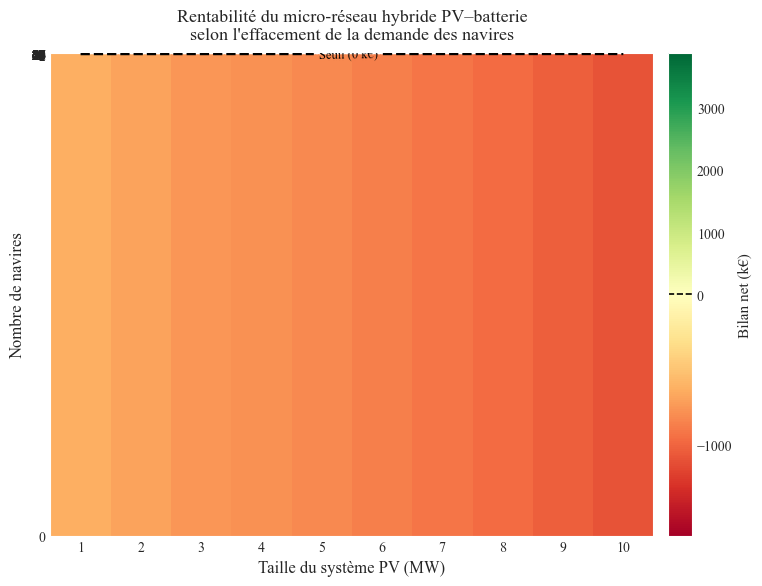

✓ Figure sauvegardée : rentabilite_microgrid_heatmap.pdf / .png


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from matplotlib.colors import TwoSlopeNorm

# ── 1. Données ────────────────────────────────────────────────────────────────
df_results = pd.read_csv("resultats_simulation.csv")

pivot = df_results.pivot(
    index="Nombre de navires",   # ← ordonnée
    columns="Taille PV (MW)",    # ← abscisse
    values="Bilan Net (k€)"
)

Z = pivot.values
X = pivot.columns.values   # tailles PV
Y = pivot.index.values     # nombres de navires

# ── 2. Style publication ───────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":     "serif",
    "font.serif":      ["Times New Roman", "DejaVu Serif"],
    "font.size":       11,
    "axes.labelsize":  12,
    "axes.titlesize":  13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth":  0.8,
})

# ── 3. Normalisation divergente centrée sur 0 ─────────────────────────────────
vmin, vmax = np.nanmin(Z), np.nanmax(Z)
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

# ── 4. Bords de cellules ───────────────────────────────────────────────────────
def log_edges(arr):
    """Calcule les bords de cellules en espace logarithmique."""
    log_arr = np.log10(arr)
    edges = np.concatenate([
        [log_arr[0] - (log_arr[1] - log_arr[0]) / 2],
        (log_arr[:-1] + log_arr[1:]) / 2,
        [log_arr[-1] + (log_arr[-1] - log_arr[-2]) / 2],
    ])
    return 10**edges

X_edges = np.concatenate([
    [X[0] - (X[1] - X[0]) / 2],
    (X[:-1] + X[1:]) / 2,
    [X[-1] + (X[-1] - X[-2]) / 2],
])
Y_edges = log_edges(Y)

# ── 5. Figure ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

# — Heatmap de fond —
im = ax.pcolormesh(
    X_edges, Y_edges, Z,
    cmap="RdYlGn",
    norm=norm,
    shading="flat",
    zorder=1,
)

# — Courbe de niveau zéro (seuil de rentabilité) —
CS = ax.contour(
    X, Y, Z,
    levels=[0],
    colors=["black"],
    linewidths=1.8,
    linestyles="--",
    zorder=3,
)
ax.clabel(CS, fmt="Seuil (0 k€)", fontsize=9, inline=True, inline_spacing=6)

# — Contours de référence —
CS2 = ax.contour(
    X, Y, Z,
    levels=np.linspace(vmin, vmax, 9),
    colors="white",
    linewidths=0.4,
    alpha=0.35,
    zorder=2,
)

# ── 6. Échelle log sur Y ───────────────────────────────────────────────────────
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(mticker.NullFormatter())
ticks_a_afficher = [1, 2, 5, 10, 20, 30, 50, 70]
ax.set_yticks([t for t in ticks_a_afficher if t in Y])
ax.set_yticks(Y)   # un tick par valeur de navires

# ── 7. Colorbar ────────────────────────────────────────────────────────────────
cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("Bilan net (k€)", fontsize=11)
cbar.ax.axhline(
    (0 - vmin) / (vmax - vmin),   # position normalisée du 0
    color="black",
    linewidth=1.2,
    linestyle="--",
)

# ── 8. Axes & titre ────────────────────────────────────────────────────────────
ax.set_xlabel("Taille du système PV (MW)")
ax.set_ylabel("Nombre de navires")
ax.set_title(
    "Rentabilité du micro-réseau hybride PV–batterie\n"
    "selon l'effacement de la demande des navires",
    pad=10,
)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# ── 9. Export ──────────────────────────────────────────────────────────────────
fig.tight_layout()
fig.savefig("rentabilite_microgrid_heatmap.pdf", dpi=300, bbox_inches="tight")
fig.savefig("rentabilite_microgrid_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Figure sauvegardée : rentabilite_microgrid_heatmap.pdf / .png")